# Rewrite of the Spherical Surface Problem

This problem is different from the original droplet impact problem because it introduces a non-linearity in the contact conditions. This fundamentally alters the solution of the non-linear system, requiring the use of Newton's Method. 

The discrete optimization structure is unchanged from the original algorithm, but now we need a robust non-linear solver and a clearer acceptance and rejection criteria. 

One idea can be:
- Inner-problem (non-linear): for a fixed q, solve F (x) = 0 using Newton's Method
- Outer problem (discrete): Evaluate epsilon_q = max(epsilon_1,q, epsilon_2,q) and choose m = argmin_q(epsilon_q)
- Adaptative timestep: reject steps if m changes too fast (the solution is invalid and we halve epsilon_t)

What's happening in each time step?

1. A non-linear root-finding problem for a fixed contact index q, the convergence criterion is the norm ||F(x)||
2. A discrete minimimization problem over q (for choosing the optimal contact size)
3. A time stepping problem (advancing k -> k + 1)

## Main imports 

In [ ]:
"""import Pkg; Pkg.add("Animations")
import Pkg; Pkg.add("Colors")
import Pkg; Pkg.add("ColorSchemes")
import Pkg; Pkg.add("GLMakie")"""

In [ ]:
using LinearAlgebra
using SpecialFunctions
using FastGaussQuadrature
using DelimitedFiles
using ProgressMeter
using Printf
using LegendrePolynomials
using ColorSchemes

# For 3D plotting and animation
using Plots
using GeometryBasics: Point3f0, TriangleFace, Mesh
using GLMakie
using CairoMakie
using Statistics
using Animations
using Colors
plotlyjs()

## Non linear Tolerances 

In [ ]:
# explicit Newton Solver Tolerance here
const NEWTON_TOL_F = 1e-8
const NEWTON_TOL_X = 1e-10
const NEWTON_MAXIT = 25
const MAX_DT_HALVINGS = 10


## User input variables

In [ ]:
#Physical ants
rho_in_CGS = 1 #Gr/cm^3
sigma_in_CGS = 72 #Dyne/cm
g_in_CGS = 980 #Cm/s2
nu_in_GCS = 0.01 #cm2/s

#Geometry
R_in_CGS = 0.02 #Cm
R_s = 0.01 # Spherical substrate radius
Ra = R_s / R_in_CGS  # Dimensionless substrate radius ratio

#Initial speed in meters per second
V_in_CGS = 30 #Cm/s

#Total simulation time
T_end = 5 #In dimensionless units

#Numerical parameters
n_thetas = 40
n_sampling_time_L_mode = 16 #Not any less than 8

## User input derived variables

In [ ]:
# Initial height
H_in_CGS = R_in_CGS # centimeter-gram-second

# Units
unit_length_in_CGS = R_in_CGS
unit_time_in_CGS = sqrt(rho_in_CGS * R_in_CGS^3 / sigma_in_CGS)
unit_mass_in_CGS = rho_in_CGS * R_in_CGS^3

# Dimensionless constants
We = rho_in_CGS * V_in_CGS^2 * R_in_CGS / sigma_in_CGS
Bo = rho_in_CGS * g_in_CGS * R_in_CGS^2 / sigma_in_CGS
Oh = nu_in_GCS * sqrt(rho_in_CGS / (sigma_in_CGS * R_in_CGS))

# Numerical constants
delta_time_max = (2 * pi) / (sqrt(n_thetas * (n_thetas + 2) * (n_thetas - 1)) * n_sampling_time_L_mode)
n_times_base = ceil(Int, T_end / delta_time_max)

# Initialize list of times
times_list = collect(0:delta_time_max:(n_times_base*delta_time_max))

# Dimensionless initial conditions
V = -sqrt(We)
H = H_in_CGS / unit_length_in_CGS

# Define vector of cosines of the sampled angles
roots, weights = gausslegendre(n_thetas)
cos_theta_vec = vcat(1, reverse(roots))
theta_vec = acos.(cos_theta_vec)
q_last = findfirst(x -> x <= 0, cos_theta_vec) - 1

## Governing Equations

In [ ]:
function F(x, q, params)
    # momentum balance
    # curvature
    # spherical kinematics
    return Fvec
end


## Jacobian

In [ ]:
function J(x, q, params)
    return Jmat
end

## Geometry Checks

In [ ]:
function geometry_valid(x, q, params)
    # sqrt radicands ≥ 0
    # no penetration outside contact
    return true or false
end


# Newton's Method Solver

In [ ]:
const DEBUG_NEWTON = true
const LM_MAX_TRIES = 8
const LM_LAMBDA0 = 1e-6

function newton_solve(x0, q, params)
    x = copy(x0)

    for _ in 1:NEWTON_MAXIT
        Fx = F_system(x, q, params)
        if !all(isfinite, Fx)
            DEBUG_NEWTON && println("newton fail: nonfinite F")
            return x, false
        end
        if norm(Fx, Inf) <= NEWTON_TOL_F
            return x, true
        end

        Jx = J_system(x, q, params)
        if any(isnan.(Jx)) || any(z -> !isfinite(z), Jx)
            DEBUG_NEWTON && println("newton fail: nonfinite J")
            return x, false
        end

        Fx_norm = norm(Fx)  # use 2-norm for smoother acceptance

        # --- Candidate directions: Newton first, then LM if needed ---
        directions = Vector{Vector{Float64}}()

        # Newton direction
        deltaN = try
            Jx \ (-Fx)
        catch
            DEBUG_NEWTON && println("newton fail: J\\F threw")
            return x, false
        end
        all(isfinite, deltaN) || (DEBUG_NEWTON && println("newton fail: nonfinite delta_x"); return x, false)
        push!(directions, deltaN)

        # LM directions (added only if Newton backtracking fails)
        function try_direction!(delta_x)
            alpha = 1.0
            for _ in 1:NEWTON_MAX_BACKTRACK
                x_trial = x .+ alpha .* delta_x
                A_trial, U_trial, B_trial, h_trial, v_trial = unpack_x(x_trial)
                if !geometry_valid(A_trial, h_trial, q, params[end])
                    DEBUG_NEWTON && println("newton: geometry invalid at alpha=$alpha")
                    alpha *= 0.5
                    continue
                end

                F_trial = F_system(x_trial, q, params)
                if !all(isfinite, F_trial)
                    DEBUG_NEWTON && println("newton: nonfinite F_trial")
                    alpha *= 0.5
                    continue
                end

                if norm(F_trial) < Fx_norm
                    x .= x_trial
                    return true
                end

                alpha *= 0.5
            end
            DEBUG_NEWTON && println("newton: Solution not accepted at alpha=$(alpha)")
            return false
        end

        # Try Newton direction first
        if try_direction!(directions[1])
            continue
        end

        # LM fallback: try increasing lambda
        JT = transpose(Jx)
        g = -(JT * Fx)

        n = length(x)
        I_n = Matrix{Float64}(I, n, n)

        λ = LM_LAMBDA0
        accepted = false
        for k in 1:LM_MAX_TRIES
            A = JT * Jx + λ * I_n
            deltaLM = try
                A \ g
            catch
                DEBUG_NEWTON && println("LM fail: solve threw at λ=$λ")
                λ *= 10
                continue
            end
            if !all(isfinite, deltaLM)
                DEBUG_NEWTON && println("LM fail: nonfinite step at λ=$λ")
                λ *= 10
                continue
            end

            DEBUG_NEWTON && println("LM: trying λ=$λ")
            if try_direction!(deltaLM)
                accepted = true
                break
            end
            λ *= 10
        end

        if !accepted
            DEBUG_NEWTON && println("newton fail: backtracking failed (Newton + LM)")
            return x, false
        end

        # Optional small-step convergence check
        # (use Inf-norm here if you like, doesn't matter much)
        if norm(F_system(x, q, params), Inf) <= NEWTON_TOL_F
            return x, true
        end
    end

    return x, false
end

In [ ]:
function newton_solve(x0, q, params)
    x = x0
    for it in 1:NEWTON_MAXIT
        Fx = F(x, q, params)
        if norm(Fx) < NEWTON_TOL_F
            return x, true
        end
        Jx = J(x, q, params)
        Δx = Jx \ (-Fx)

        # damp if needed
        x = x + Δx
    end
    return x, false
end


## Epsilon Definitions

In [ ]:
function epsilon(x, q, params)
    e1 = geometry_valid(x, q, params) ? 0.0 : Inf
    e2 = boundary_mismatch(x, q, params)
    return max(e1, e2)
end


## Single-q evaluation wrapper

In [ ]:
function evaluate_q(x0, q, params)
    x, converged = newton_solve(x0, q, params)
    if !converged
        return Inf, nothing
    end
    ε = epsilon(x, q, params)
    return ε, x
end


## Contact selection logic

In [ ]:
function select_q(x_prev, q_prev, params)
    candidates = q_prev .+ (-2:2)
    best_q = nothing
    best_ε = Inf
    best_x = nothing

    for q in candidates
        ε, x = evaluate_q(x_prev, q, params)
        if ε < best_ε
            best_ε = ε
            best_q = q
            best_x = x
        end
    end
    return best_q, best_x, best_ε
end


## Time stepping loop

In [ ]:
while t < t_final
    q_new, x_new, ε = select_q(x, q, params)

    if ε == Inf
        Δt /= 2
        continue
    end

    x = x_new
    q = q_new
    t += Δt
end


In [9]:
# draw the spherical substrate surface
function draw_spherical_substrate!(ax, Ra, layers=60)
    phi = range(0, 2*pi, length=layers)
    theta_sphere = range(0, pi / 2, length=30)

    x_sphere = zeros(length(theta_sphere), layers)
    y_sphere = zeros(length(theta_sphere), layers)
    z_sphere = zeros(length(theta_sphere), layers)

    for (i, θ) in enumerate(theta_sphere)
        for (j, ϕ) in enumerate(phi)
            x_sphere[i, j] = Ra * sin(θ) * cos(ϕ)
            y_sphere[i, j] = Ra * sin(θ) * sin(ϕ)
            z_sphere[i, j] = Ra * (cos(θ)-1)
        end
    end

    GLMakie.surface!(ax, x_sphere, y_sphere, z_sphere, colormap=:grays, alpha=0.7)
end

draw_spherical_substrate! (generic function with 2 methods)

In [10]:
R_in_CGS = 0.02 #Cm
R_s = 0.01 # Spherical substrate radius
Ra = R_s / R_in_CGS  # Dimensionless substrate radius ratio

0.5

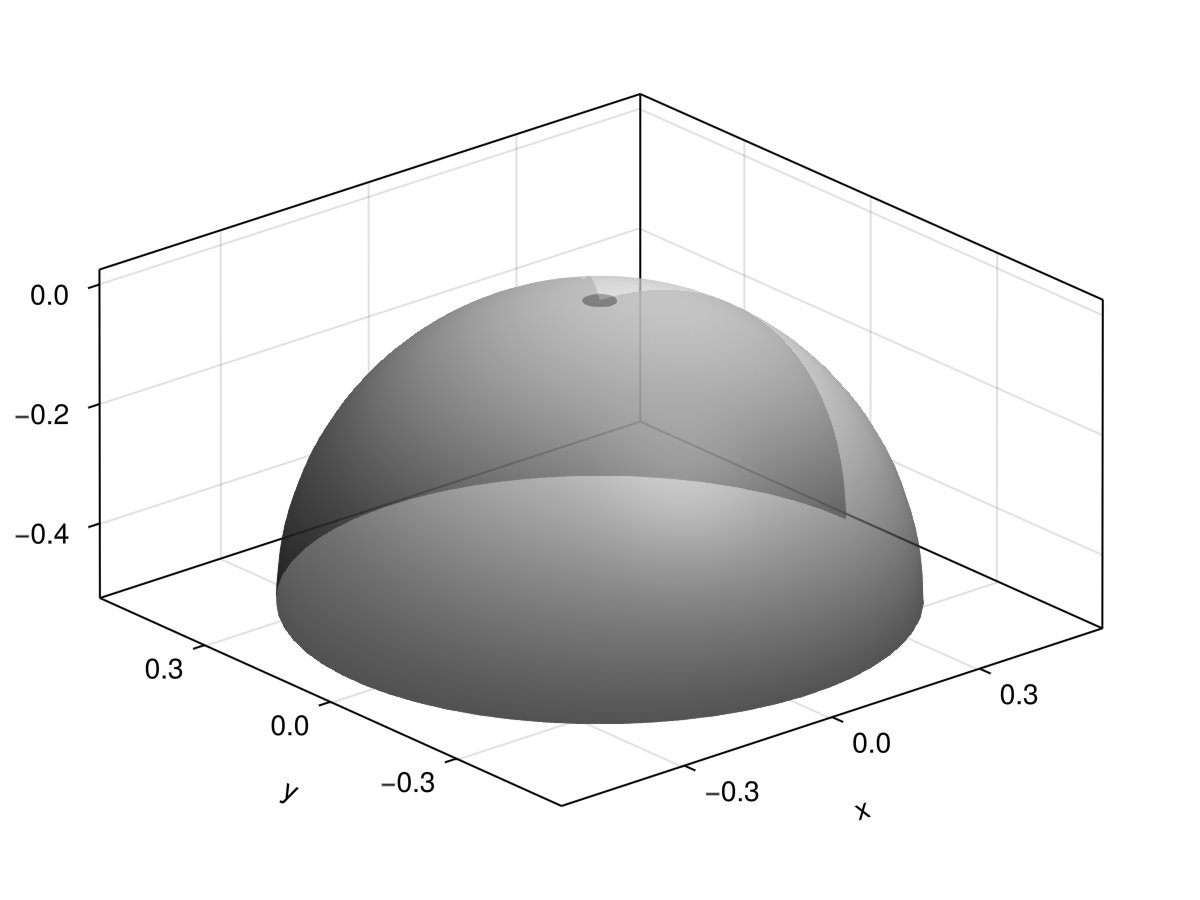

In [11]:
using GLMakie

fig = GLMakie.Figure()
ax = GLMakie.Axis3(fig[1, 1]; aspect = :data)   # key line
draw_spherical_substrate!(ax, Ra)
fig

In [ ]:
r = Ra
GLMakie.limits!(ax, (-r, r), (-r, r), (-r, r))  # or a range you want

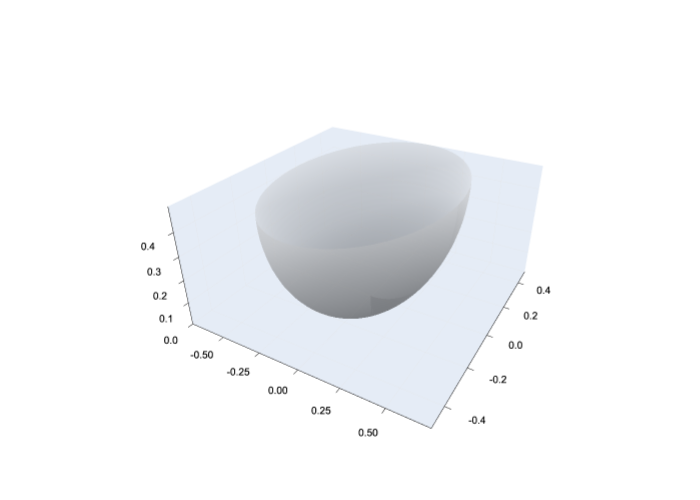

In [4]:
using Plots
plotlyjs()

function substrate_surface_arrays(Ra; layers=60, nθ=30)
    phi = range(0, 2*pi, length=layers)
    theta_sphere = range(0, pi/2, length=nθ)

    x = zeros(length(theta_sphere), length(phi))
    y = similar(x)
    z = similar(x)

    for (i, θ) in enumerate(theta_sphere)
        for (j, ϕ) in enumerate(phi)
            x[i, j] = Ra * sin(θ) * cos(ϕ)
            y[i, j] = Ra * sin(θ) * sin(ϕ)
            z[i, j] = Ra * (1 - cos(θ))
        end
    end

    return x, y, z
end

x, y, z = substrate_surface_arrays(Ra)
plt = surface(x, y, z; c=:grays, alpha=0.6, legend=false, aspect_ratio=:equal)
display(plt)